#HORIZON BANK (HRB)

##Dataset Overview


*   Customer demographics
*   Account & product information
*   Churn label

Import Library

In [ ]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import data set dari kagglehub

In [ ]:
#Download latest version
import kagglehub
path = kagglehub.dataset_download("dyutimazumder/banking-customer-churn-analysis")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'banking-customer-churn-analysis' dataset.
Path to dataset files: /kaggle/input/banking-customer-churn-analysis


Mengecek isi data isi folder dari data set

In [ ]:
#Mengecek data isi folder dari data set
import os
os.listdir(path)

['Churn Modelling Dataset.csv', 'Banking Customer Churn Analysis.pbix']

Memindahkan dataset ke Pandas

In [ ]:
#Load dataset ke pandas
import pandas as pd

file_path = "/kaggle/input/banking-customer-churn-analysis/Churn Modelling Dataset.csv"
df = pd.read_csv(file_path)

#Lihat 5 baris pertama
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Mengecek data

In [ ]:
#Jumlah baris & kolom
df.shape

(10000, 14)

In [ ]:
#Info kolom & tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
#Statistik deskriptif awal
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


#DEEP Milestone 2

## 2.1 Data Cleaning

##a) Cek missing value

In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


##b) Cek duplikat data

In [ ]:
#Check duplikat data
df.duplicated().sum()

np.int64(0)

In [ ]:
#cek data setelah cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
#memasukan kode warna sesuai dengan deck DEEP
import matplotlib.pyplot as plt

PRIMARY = '#0E1D40'    # Navy
ACCENT = '#CCF5AC'     # Green
BACKGROUND = '#F1F0F8' # Light

plt.rcParams['figure.facecolor'] = BACKGROUND
plt.rcParams['axes.facecolor'] = BACKGROUND
plt.rcParams['axes.edgecolor'] = PRIMARY
plt.rcParams['axes.labelcolor'] = PRIMARY
plt.rcParams['xtick.color'] = PRIMARY
plt.rcParams['ytick.color'] = PRIMARY
plt.rcParams['text.color'] = PRIMARY


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()


In [ ]:
model.fit(X_train, y_train)


ValueError: could not convert string to float: "P'an"

#2.2 EXPLORATORY DATA ANALYSIS (EDA)

##A) Customer Profile

###A.1 Churn Rate by Geography (geography)

In [ ]:
#churn vs geography
import pandas as pd
import matplotlib.pyplot as plt

churn_geo = df.groupby('Geography')['Exited'].agg(['count', 'sum']).reset_index()
churn_geo.columns = ['Geography', 'Total_Customers', 'Churned_Customers']
churn_geo['Churn_Rate'] = churn_geo['Churned_Customers'] / churn_geo['Total_Customers'] * 100

churn_geo

,Geography,Total_Customers,Churned_Customers,Churn_Rate
0,France,5014,810,16.154767
1,Germany,2509,814,32.443204
2,Spain,2477,413,16.673395


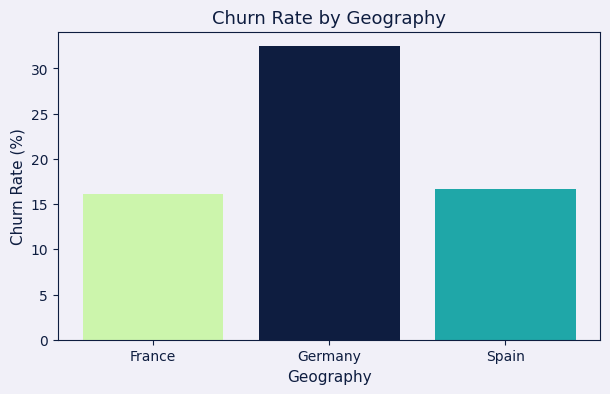

In [ ]:
#chart
import pandas as pd
import matplotlib.pyplot as plt

# Hitung churn rate per negara
churn_geo = df.groupby('Geography')['Exited'].agg(['count', 'sum']).reset_index()
churn_geo.columns = ['Geography', 'Total_Customers', 'Churned_Customers']
churn_geo['Churn_Rate'] = churn_geo['Churned_Customers'] / churn_geo['Total_Customers'] * 100

# Urutkan biar sama seperti Tableau (France, Germany, Spain) kalau perlu
order = ['France', 'Germany', 'Spain']
churn_geo['Geography'] = pd.Categorical(churn_geo['Geography'], categories=order, ordered=True)
churn_geo = churn_geo.sort_values('Geography')

# Warna sesuai deck
color_map = {
    'France': '#CCF5AC',   # green highlight
    'Germany': '#0E1D40',  # navy
    'Spain': '#1FA7A8'     # teal
}

colors = churn_geo['Geography'].map(color_map)

# Plot
plt.figure(figsize=(7,4))
plt.bar(churn_geo['Geography'], churn_geo['Churn_Rate'], color=colors)

plt.xlabel('Geography', fontsize=11)
plt.ylabel('Churn Rate (%)', fontsize=11)
plt.title('Churn Rate by Geography', fontsize=13)

plt.show()


Insight : Germany exhibits the highest churn rate (~32%), nearly double that of France (~16%) and Spain (~17%), indicating a significantly higher attrition risk concentrated in the German market.

Business meaning:
The elevated churn in Germany suggests underlying issues related to customer engagement, product fit, or service experience that are more pronounced than in other markets. This indicates the need for country-specific retention strategies rather than a uniform approach across all regions.

###A.2 Churn Rate by Age Group (Age)

###Churn by Age

/tmp/ipython-input-388546138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


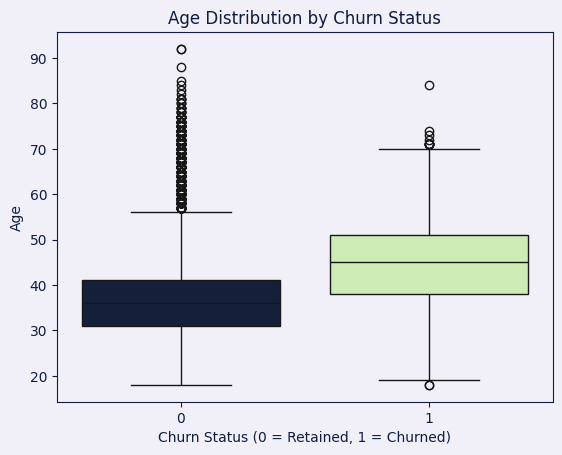

In [ ]:
#age vs churn
sns.boxplot(
    data=df,
    x="Exited",
    y="Age",
    palette=["#0E1D40", "#CCF5AC"]
)

plt.title("Age Distribution by Churn Status", color="#0E1D40")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Age")
plt.show()

Insight :The median age of churned customers is **older than** that of retained customers.

The variability in churned customers' ages is greater.

Business meaning: Older customers may:

Be less comfortable with digital banking

Be more sensitive to service and competitor offerings.

### Churn rate by Age group

In [ ]:
#cek data culomn age group dan Churn Rate
df.columns


Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Age_Group'],
      dtype='object')

In [ ]:
#memakai exited (0 = stay, 1 = churn) dan Exited ganti nama Churn rate
age_churn = (
    df.groupby('Age_Group')['Exited']
    .mean()
    .reset_index(name='Churn_Rate')
)


/tmp/ipython-input-122630993.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Exited']


In [ ]:
#hitungan menggroup kan umur dan churn rate
display(age_churn)

,Age_Group,Churn_Rate,Churn_Rate_Pct
0,18–30,0.075026,7.502569
1,31–40,0.120872,12.087171
2,41–50,0.339655,33.965517
3,50+,0.446471,44.647105


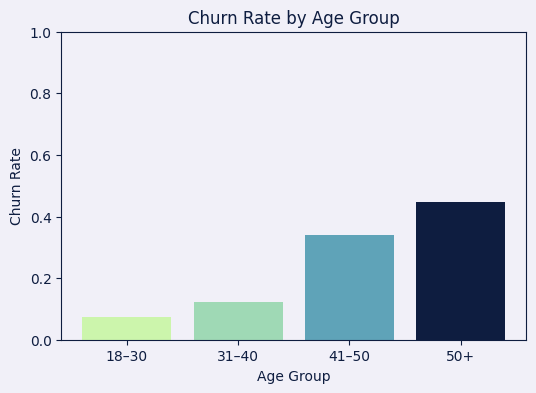

In [ ]:
#chart tanpa persentase
colors = ['#CCF5AC', '#9FD9B5', '#5FA3B8', '#0E1D40']

plt.figure(figsize=(6,4))
plt.bar(
    age_churn['Age_Group'],
    age_churn['Churn_Rate'],
    color=colors
)

plt.xlabel('Age Group')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Age Group')

plt.ylim(0, 1)
plt.show()


In [ ]:
#Churn rate dalam betuk persentase per age group
age_churn['Churn_Rate_Pct'] = age_churn['Churn_Rate'] * 100
age_churn


,Age_Group,Churn_Rate,Churn_Rate_Pct
0,18–30,0.075026,7.502569
1,31–40,0.120872,12.087171
2,41–50,0.339655,33.965517
3,50+,0.446471,44.647105


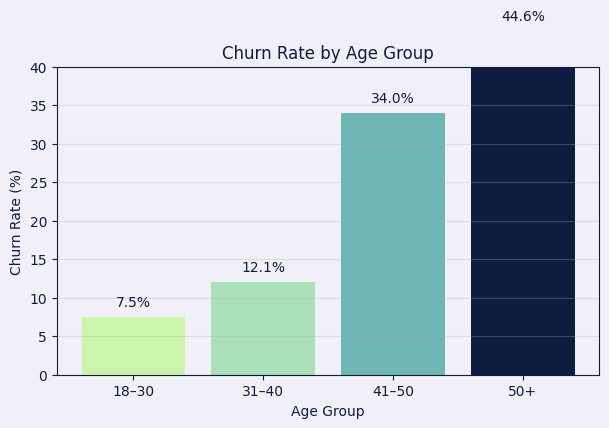

In [ ]:
#chart pakai persentase
import matplotlib.pyplot as plt

# Warna gradien sesuai level churn (low → high)
colors = ['#CCF5AC', '#A9E0B8', '#6FB7B5', '#0E1D40']

plt.figure(figsize=(7,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    age_churn['Age_Group'],
    age_churn['Churn_Rate_Pct'],
    color=colors
)

# Label persentase di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Age Group')

plt.ylim(0, 40)
plt.grid(axis='y', alpha=0.3)

plt.show()


Insight:

Churn rate rises sharply with age, peaking at 44.6% among customers aged 50+.
**Business Meaning:**

Senior customer segments face higher churn risk, indicating potential gaps in product relevance and service experience.

###A.3 Churn Rate by Credit Score Band (Credit Characteristic)

In [ ]:
#cek culomn CreditScore dan Churn
df.columns


Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Age_Group', 'Credit_Band'],
      dtype='object')

In [ ]:
#data bins pengelompokan score brand berdasarkan labels
df['Credit_Band'] = pd.cut(
    df['CreditScore'],
    bins=[300, 580, 670, 740, 800, 900],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
)


In [ ]:
#hitung churn rate=Exited karena tidak ada culomn churn rate Exited = 1 (churn), 0 (stay)
credit_churn = (
    df.groupby('Credit_Band', observed=False)['Exited']
    .mean()
    .reset_index(name='Churn_Rate')
)

credit_churn

,Credit_Band,Churn_Rate
0,Poor,0.221479
1,Fair,0.203881
2,Good,0.188152
3,Very Good,0.202469
4,Excellent,0.196899


In [ ]:
#churn rate resiko tertinggi
credit_churn_sorted = credit_churn.sort_values(
    by='Churn_Rate',
    ascending=False
)


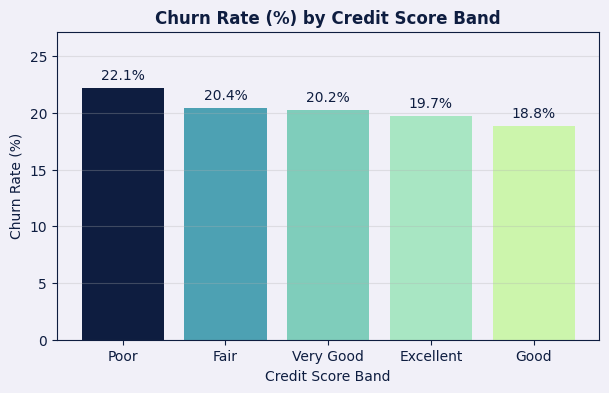

In [ ]:
import matplotlib.pyplot as plt

colors = ['#0E1D40', '#4DA1B3', '#7FCDBB', '#A8E6C3', '#CCF5AC']

plt.figure(figsize=(7,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    credit_churn_sorted['Credit_Band'],
    credit_churn_sorted['Churn_Rate'] * 100,
    color=colors
)

# Label persentase di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Churn Rate (%) by Credit Score Band', weight='bold')
plt.xlabel('Credit Score Band')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(credit_churn_sorted['Churn_Rate'] * 100) + 5)
plt.grid(axis='y', alpha=0.3)

plt.show()



Insight : Poor: 22.1% → churn tertinggi

Fair: 20.4%

Very Good: 20.2%

Excellent: 19.7%

Good: 18.8% → churn terendah
Customers with lower credit scores exhibit higher churn rates.

**Business Meaning:**

Credit score reflects financial stability and serves as an effective indicator of churn risk.

###Insight Customer Profile Overall Insight:
Customer demographics and geography influence churn distribution but are contextual drivers, not the strongest predictors.

##B) Financial Behavior

###B.1 Average Account Balance by Churn Status (Account Balance)

In [ ]:
#hitung balance by churn=exited
balance_churn = (
    df.groupby('Exited')['Balance']
      .mean()
      .reset_index()
)


In [ ]:
#merubah labelnya exited = 1 (Churn), 0 (Non Churn)
balance_churn['Churn_Status'] = balance_churn['Exited'].map({
    0: 'Non-Churn',
    1: 'Churn'
})

balance_churn


,Exited,Balance,Churn_Status
0,0,72745.296779,Non-Churn
1,1,91108.539337,Churn


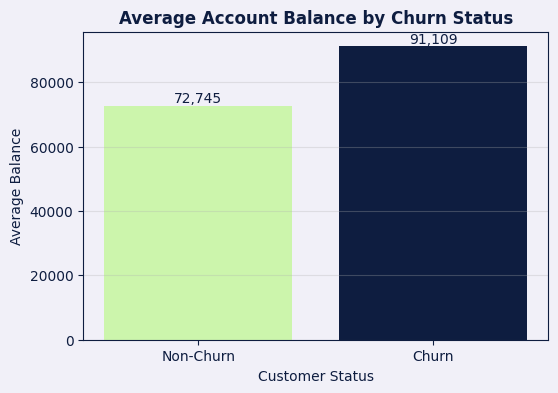

In [ ]:
#chart
import matplotlib.pyplot as plt

colors = ['#CCF5AC', '#0E1D40']  # Non-Churn, Churn

plt.figure(figsize=(6,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    balance_churn['Churn_Status'],
    balance_churn['Balance'],
    color=colors
)

# Label angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Average Account Balance by Churn Status', weight='bold')
plt.xlabel('Customer Status')
plt.ylabel('Average Balance')
plt.grid(axis='y', alpha=0.3)

plt.show()


In [ ]:
#menjadi persentase
total_avg_balance = balance_churn['Balance'].sum()

balance_churn['Balance_Pct'] = (
    balance_churn['Balance'] / total_avg_balance * 100
)

balance_churn


,Exited,Balance,Churn_Status,Balance_Pct
0,0,72745.296779,Non-Churn,44.396456
1,1,91108.539337,Churn,55.603544


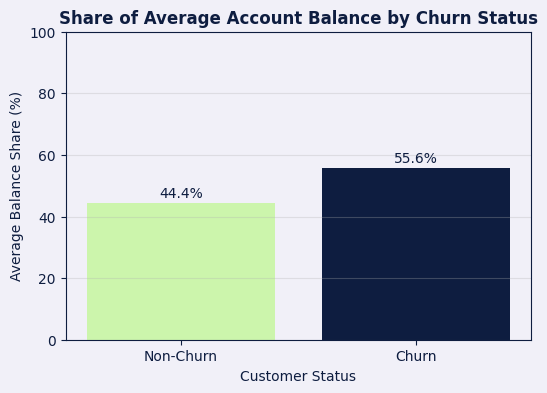

In [ ]:
#chart persentase
import matplotlib.pyplot as plt

colors = ['#CCF5AC', '#0E1D40']

plt.figure(figsize=(6,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    balance_churn['Churn_Status'],
    balance_churn['Balance_Pct'],
    color=colors
)

# Label persentase di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Share of Average Account Balance by Churn Status', weight='bold')
plt.xlabel('Customer Status')
plt.ylabel('Average Balance Share (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.show()


Insight : Churn: ≈ 55.6% dari total average balance

Non-Churn: ≈ 44.4% dari total average balance.
Churned customers account for a larger share of the bank’s average account balance than retained customers.
**Business meaning** : Customer churn represents a significant financial risk, as high-value customers contribute disproportionately to balance loss. Customer churn leads to disproportionate financial loss due to the exit of high-value customers.

###B.2 Transaction Activity Proxy vs Churn (Transaction Activity=Proxy)



In [ ]:
#Proxy: EstimatedSalary (Exited) = 1 dan 0
salary_churn = (
    df.groupby('Exited')['EstimatedSalary']
    .mean()
    .reset_index()
)

salary_churn['Churn_Status'] = salary_churn['Exited'].map({
    0: 'Non-Churn',
    1: 'Churn'
})

salary_churn


,Exited,EstimatedSalary,Churn_Status
0,0,99738.391772,Non-Churn
1,1,101465.677531,Churn


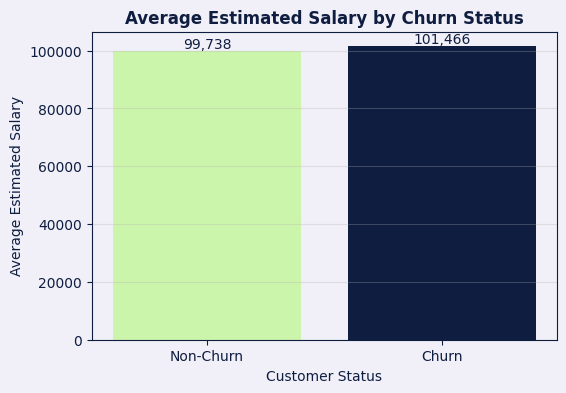

In [ ]:
#chart
import matplotlib.pyplot as plt

colors = ['#CCF5AC', '#0E1D40']

plt.figure(figsize=(6,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    salary_churn['Churn_Status'],
    salary_churn['EstimatedSalary'],
    color=colors
)

# Label angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Average Estimated Salary by Churn Status', weight='bold')
plt.xlabel('Customer Status')
plt.ylabel('Average Estimated Salary')
plt.grid(axis='y', alpha=0.3)

plt.show()


In [ ]:
#menjadi persentase
total_avg_salary = salary_churn['EstimatedSalary'].sum()

salary_churn['Salary_Pct'] = (
    salary_churn['EstimatedSalary'] / total_avg_salary * 100
)

salary_churn


,Exited,EstimatedSalary,Churn_Status,Salary_Pct
0,0,99738.391772,Non-Churn,49.570763
1,1,101465.677531,Churn,50.429237


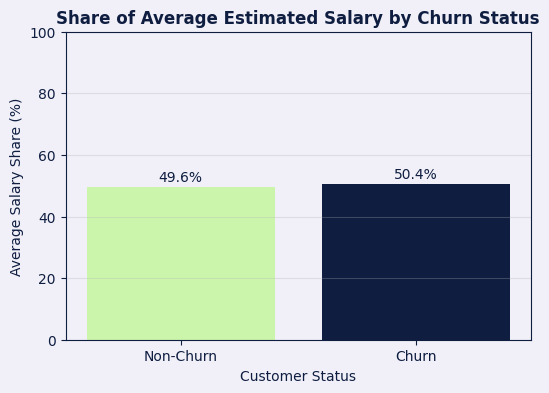

In [ ]:
#chart
import matplotlib.pyplot as plt

colors = ['#CCF5AC', '#0E1D40']

plt.figure(figsize=(6,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    salary_churn['Churn_Status'],
    salary_churn['Salary_Pct'],
    color=colors
)

# Label persentase di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Share of Average Estimated Salary by Churn Status', weight='bold')
plt.xlabel('Customer Status')
plt.ylabel('Average Salary Share (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.show()


Insight:

Churned customers and retained customers contribute almost equally to the total average estimated salary. Churn: ≈ 50.4%. Non-Churn: ≈ 49.6%. Average estimated salary contribution is nearly equal between churned and non-churned customers.
**Business meaning :** Customer churn is largely independent of income level and is more influenced by engagement and service-related factors. Income level alone is not a strong driver of customer churn.

###Overall Insight Financial Behavior:
Financial behavior highlights early churn signals, especially among customers with low balances and limited activity.

##C) Enggament Product Usage

###C.1 Churn Rate by Customer Tenure (Customer Tuner)

In [ ]:
#bin pengemlompokan dan pelabelan
df['Tenure_Group'] = pd.cut(
    df['Tenure'],
    bins=[0,2,5,10],
    labels=['0–2 yrs','3–5 yrs','6–10 yrs']
)


In [ ]:
#hitung churn(exited) vs tenure
tenure_churn = (
    df.groupby('Tenure_Group')['Exited']
      .mean()
      .reset_index()
)
tenure_churn

/tmp/ipython-input-3152694583.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Tenure_Group')['Exited']


,Tenure_Group,Exited
0,0–2 yrs,0.207873
1,3–5 yrs,0.207641
2,6–10 yrs,0.196707


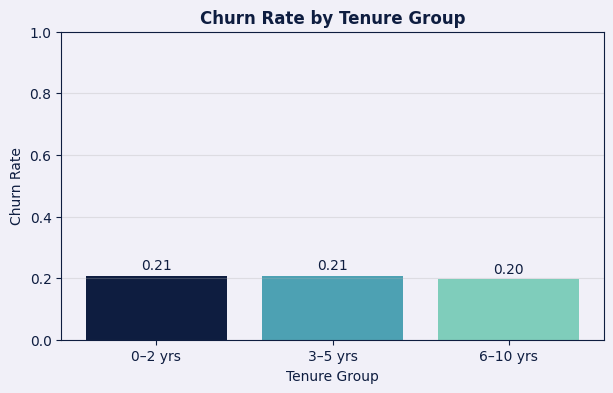

In [ ]:
#chart
import matplotlib.pyplot as plt

colors = ['#0E1D40', '#4DA1B3', '#7FCDBB', '#CCF5AC']

plt.figure(figsize=(7,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    tenure_churn['Tenure_Group'],
    tenure_churn['Exited'],
    color=colors[:len(tenure_churn)]
)

# Label churn rate (decimal) di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Churn Rate by Tenure Group', weight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()


In [ ]:
#to persentase
tenure_churn = (
    df.groupby('Tenure_Group')['Exited']
      .mean()
      .reset_index(name='Churn_Rate')
)

# Ubah ke persen
tenure_churn['Churn_Rate_Pct'] = tenure_churn['Churn_Rate'] * 100

tenure_churn


/tmp/ipython-input-4143081777.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Tenure_Group')['Exited']


,Tenure_Group,Churn_Rate,Churn_Rate_Pct
0,0–2 yrs,0.207873,20.787326
1,3–5 yrs,0.207641,20.764120
2,6–10 yrs,0.196707,19.670672


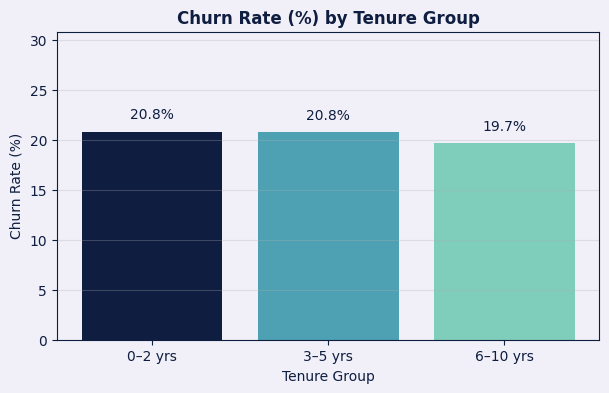

In [ ]:
#chart
import matplotlib.pyplot as plt

# Urutkan tenure dari pendek ke panjang (opsional tapi recommended)
order = tenure_churn['Tenure_Group'].tolist()

colors = ['#0E1D40', '#4DA1B3', '#7FCDBB', '#CCF5AC']

plt.figure(figsize=(7,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    tenure_churn['Tenure_Group'],
    tenure_churn['Churn_Rate_Pct'],
    color=colors[:len(tenure_churn)]
)

# Label persentase di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Churn Rate (%) by Tenure Group', weight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(tenure_churn['Churn_Rate_Pct']) + 10)
plt.grid(axis='y', alpha=0.3)

plt.show()


Insight:

Churn rate shows a slight decreasing trend as customer tenure increases.
0–2 years: ≈ 0.21 (≈ 20.8%)

3–5 years: ≈ 0.21 (≈ 20.8%)

6–10 years: ≈ 0.20 (≈ 19.7%). Churn rate decreases only slightly as tenure increases.
**BUSINESS MEANING**
Tenure alone has a limited impact on churn, indicating that longevity does not automatically guarantee customer loyalty. Longer tenure alone does not strongly protect against churn.

###C.2 Churn Rate by Activity Status (Activity Level)

In [ ]:
#churn=exited vs activity status
activity_churn = (
    df.groupby('IsActiveMember')['Exited']
      .mean()
      .reset_index()
)
# Ubah label agar readable
activity_churn['Activity_Status'] = activity_churn['IsActiveMember'].map({
    0: 'Inactive',
    1: 'Active'
})

activity_churn

,IsActiveMember,Exited,Activity_Status
0,0,0.268509,Inactive
1,1,0.142691,Active


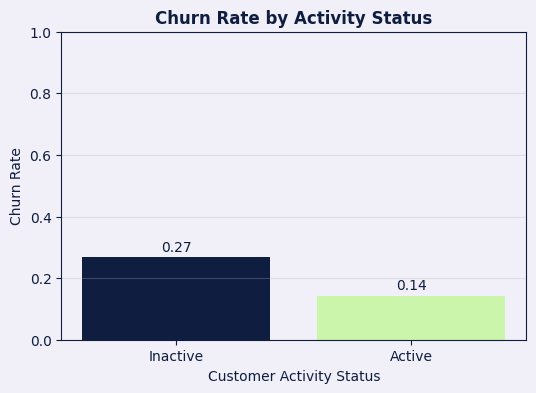

In [ ]:
#chart
import matplotlib.pyplot as plt

colors = ['#0E1D40', '#CCF5AC']  # Inactive, Active

plt.figure(figsize=(6,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    activity_churn['Activity_Status'],
    activity_churn['Exited'],
    color=colors
)

# Label churn rate (decimal) di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Churn Rate by Activity Status', weight='bold')
plt.xlabel('Customer Activity Status')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()


In [ ]:
#to persentase
activity_churn = (
    df.groupby('IsActiveMember')['Exited']
      .mean()
      .reset_index(name='Churn_Rate')
)

# Tambahkan label & persen
activity_churn['Activity_Status'] = activity_churn['IsActiveMember'].map({
    0: 'Inactive',
    1: 'Active'
})

activity_churn['Churn_Rate_Pct'] = activity_churn['Churn_Rate'] * 100

activity_churn


,IsActiveMember,Churn_Rate,Activity_Status,Churn_Rate_Pct
0,0,0.268509,Inactive,26.850897
1,1,0.142691,Active,14.269074


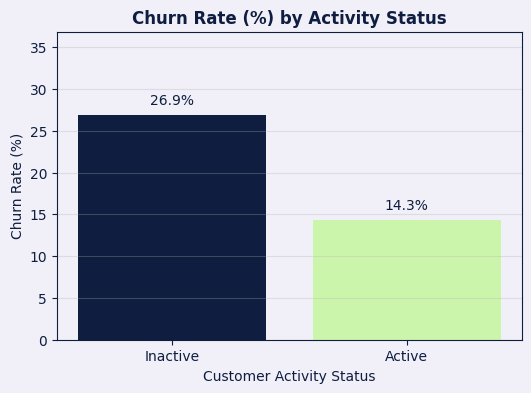

In [ ]:
#chart
import matplotlib.pyplot as plt

colors = ['#0E1D40', '#CCF5AC']  # Inactive, Active

plt.figure(figsize=(6,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    activity_churn['Activity_Status'],
    activity_churn['Churn_Rate_Pct'],
    color=colors
)

# Label persen di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Churn Rate (%) by Activity Status', weight='bold')
plt.xlabel('Customer Activity Status')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(activity_churn['Churn_Rate_Pct']) + 10)
plt.grid(axis='y', alpha=0.3)

plt.show()


Insight:

Inactive customers have nearly double the churn rate of active customers. Inactive: ≈ 26.9%
Active: ≈ 14.3%. Inactive customers show almost twice the churn rate compared to active customers.
**BUSINESS MEANING**

Customer engagement is one of the strongest predictors of churn. Improving customer engagement is critical to reducing churn.

###C.3 Churn Rate by Number of Products (Product adoption)

In [ ]:
#churn=exited 1, 0 vs product
product_count = (
    df.groupby(['NumOfProducts', 'Exited'])
      .size()
      .reset_index(name='Customer_Count')
)

# Biar readable
product_count['Churn_Status'] = product_count['Exited'].map({
    0: 'Non-Churn',
    1: 'Churn'
})

product_count


,NumOfProducts,Exited,Customer_Count,Churn_Status
0,1,0,3675,Non-Churn
1,1,1,1409,Churn
2,2,0,4242,Non-Churn
3,2,1,348,Churn
4,3,0,46,Non-Churn
5,3,1,220,Churn
6,4,1,60,Churn


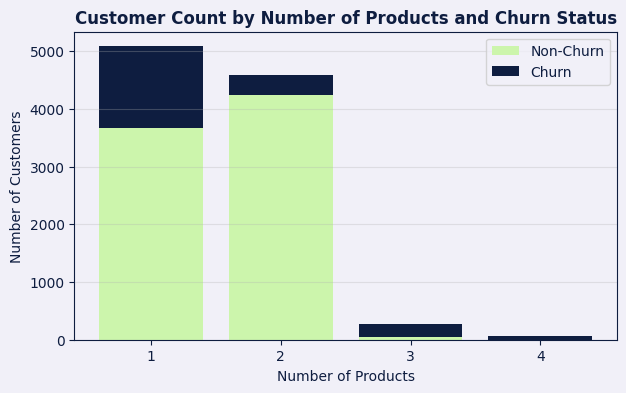

In [ ]:
#chartnya
import matplotlib.pyplot as plt
import numpy as np

# Pivot untuk chart
pivot_product = product_count.pivot(
    index='NumOfProducts',
    columns='Churn_Status',
    values='Customer_Count'
).fillna(0)

plt.figure(figsize=(7,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

plt.bar(
    pivot_product.index.astype(str),
    pivot_product['Non-Churn'],
    label='Non-Churn',
    color='#CCF5AC'
)

plt.bar(
    pivot_product.index.astype(str),
    pivot_product['Churn'],
    bottom=pivot_product['Non-Churn'],
    label='Churn',
    color='#0E1D40'
)

plt.title('Customer Count by Number of Products and Churn Status', weight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


In [ ]:
#to persentase
product_churn = (
    df.groupby('NumOfProducts')['Exited']
      .mean()
      .reset_index(name='Churn_Rate')
)

product_churn['Churn_Rate_Pct'] = product_churn['Churn_Rate'] * 100

product_churn


,NumOfProducts,Churn_Rate,Churn_Rate_Pct
0,1,0.277144,27.714398
1,2,0.075817,7.581699
2,3,0.827068,82.706767
3,4,1.000000,100.000000


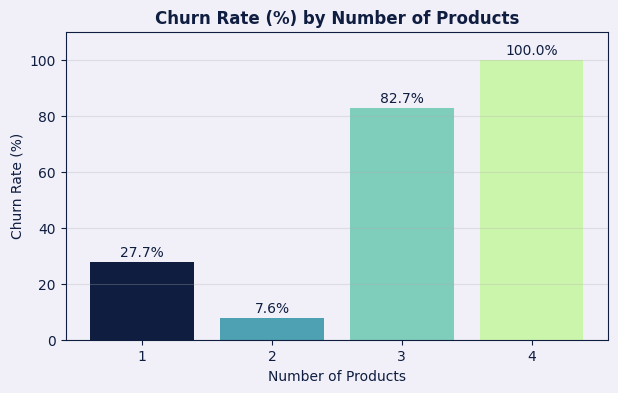

In [ ]:
#chart
import matplotlib.pyplot as plt

colors = ['#0E1D40', '#4DA1B3', '#7FCDBB', '#CCF5AC']

plt.figure(figsize=(7,4), facecolor='#F1F0F8')
ax = plt.gca()
ax.set_facecolor('#F1F0F8')

bars = plt.bar(
    product_churn['NumOfProducts'].astype(str),
    product_churn['Churn_Rate_Pct'],
    color=colors[:len(product_churn)]
)

# Label persen di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#0E1D40'
    )

plt.title('Churn Rate (%) by Number of Products', weight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(product_churn['Churn_Rate_Pct']) + 10)
plt.grid(axis='y', alpha=0.3)

plt.show()


Insight:

Customer churn shows a non-linear relationship with the number of products owned. 1 product: ~27.7% churn

2 products: ~7.6% churn (terendah)

3 products: ~82.7% churn

4 products: 100% churn. Customers with two products have the lowest churn rate, while churn increases sharply for customers with three or more products.
**BUSINESS MEANING**
There is an optimal level of product ownership that maximizes retention, while excessive product ownership may increase churn risk.Balanced product adoption improves retention, but excessive product ownership may increase churn risk.

**Overall Insight Enggament Product Usage:**
Engagement and product usage represent the most influential churn drivers, outweighing demographic and financial factors.

##D) Interaction analysis

###D.1.1 Churn Rate by Geography

In [ ]:
# Churn rate by geography tabel
geo_churn = (
    df.groupby('Geography')['Exited']
      .mean()
      .reset_index(name='Churn_Rate')
)

geo_churn


,Geography,Churn_Rate
0,France,0.161548
1,Germany,0.324432
2,Spain,0.166734


In [ ]:
#ngegroup warna
def geo_color(rate):
    if rate >= 0.25:
        return "#0E1D40"   # Navy – high churn
    elif rate >= 0.20:
        return "#4FA3B0"   # Teal – medium
    else:
        return "#CCF5AC"   # Mint – low churn


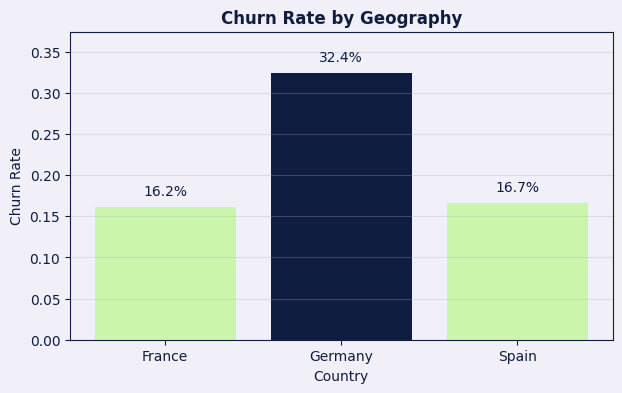

In [ ]:
#chart
geo_churn['Color'] = geo_churn['Churn_Rate'].apply(geo_color)

plt.figure(figsize=(7,4))

bars = plt.bar(
    geo_churn['Geography'],
    geo_churn['Churn_Rate'],
    color=geo_churn['Color']
)

# label persentase
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.1%}',
        ha='center',
        va='bottom',
        fontsize=10,
        color="#0E1D40"
    )

plt.title('Churn Rate by Geography', weight='bold')
plt.xlabel('Country')
plt.ylabel('Churn Rate')
plt.ylim(0, max(geo_churn['Churn_Rate']) + 0.05)
plt.grid(axis='y', alpha=0.3)

plt.show()




Key Insight:

Germany exhibits a significantly higher churn rate compared to France and Spain.

Detail angka dari visual:

Germany: 32.4% → highest churn

France: 16.2%

Spain: 16.7%

Germany has the highest churn rate at 32.4%, nearly double that of France and Spain.

BUSINESS MEANING

Geography acts as a strong contextual risk factor, with Germany representing a high-risk market.

Churn behavior varies significantly by geography, requiring market-specific retention strategies.

Recommended Actions:

🇩🇪 Germany-focused retention strategy

1. Early churn warning

2. Personalized offers

3. Service quality review

📊 Geography as segmentation feature

Wajib dimasukkan ke churn model

🧠 Interaction analysis

Geography × Activity

Geography × Product usage

###D.1.2 Geography by Activity

In [ ]:
#Geography IsActiveMember (0 = Inactive, 1 = Active), Exited (0 = Non-Churn, 1 = Churn)
geo_activity_churn = (
    df.groupby(['Geography', 'IsActiveMember'])['Exited']
      .mean()
      .reset_index(name='Churn_Rate')
)

geo_activity_churn['Churn_Rate_Pct'] = geo_activity_churn['Churn_Rate'] * 100

geo_activity_churn


,Geography,IsActiveMember,Churn_Rate,Churn_Rate_Pct
0,France,0,0.211308,21.130830
1,France,1,0.115014,11.501351
2,Germany,0,0.410785,41.078509
3,Germany,1,0.237179,23.717949
4,Spain,0,0.233476,23.347639
5,Spain,1,0.107470,10.746951


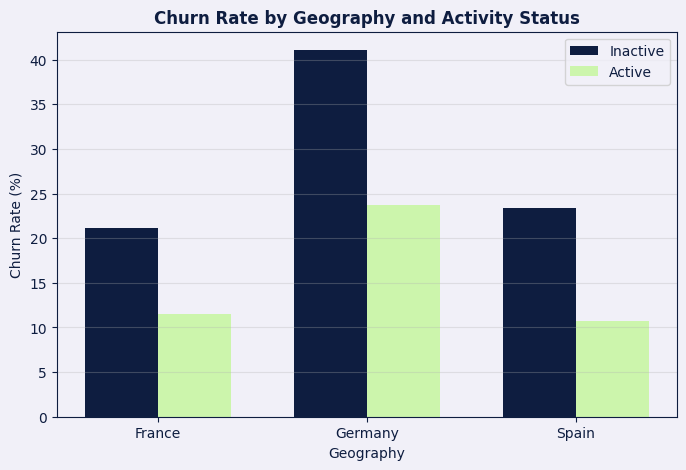

In [ ]:
#chart
NAVY = '#0E1D40'
GREEN = '#CCF5AC'
TEAL  = '#7AC7B7'

import matplotlib.pyplot as plt
import numpy as np

pivot_geo_activity = geo_activity_churn.pivot(
    index='Geography',
    columns='IsActiveMember',
    values='Churn_Rate_Pct'
)

x = np.arange(len(pivot_geo_activity.index))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, pivot_geo_activity[0],
        width, label='Inactive', color=NAVY)

plt.bar(x + width/2, pivot_geo_activity[1],
        width, label='Active', color=GREEN)

plt.xticks(x, pivot_geo_activity.index)
plt.ylabel('Churn Rate (%)')
plt.xlabel('Geography')
plt.title('Churn Rate by Geography and Activity Status', weight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


📊 Key Findings

Inactive customers consistently show higher churn rates across all countries

Germany exhibits the strongest activity–churn relationship

Inactive customers in Germany churn significantly more than active ones

In France and Spain, the churn gap between active and inactive customers is less pronounced

🧠 Interpretation

Customer engagement plays a critical role in churn, but its impact is geography-dependent.

💼 Business Meaning

Germany is highly sensitive to customer inactivity

Improving engagement in Germany yields disproportionately higher retention benefits

Activity status alone is insufficient without geographic context

🎯 Actionable Insight

Prioritize engagement-driven retention programs in Germany

Use early inactivity signals as churn alerts, especially for German customers



###D.1.3 Geography by Product Usage

In [ ]:
#Geography, NumOfProducts, Exited
geo_product_churn = (
    df.groupby(['Geography', 'NumOfProducts'])['Exited']
      .mean()
      .reset_index(name='Churn_Rate')
)

geo_product_churn['Churn_Rate_Pct'] = geo_product_churn['Churn_Rate'] * 100

geo_product_churn


,Geography,NumOfProducts,Churn_Rate,Churn_Rate_Pct
0,France,1,0.224344,22.434368
1,France,2,0.057034,5.703422
2,France,3,0.788462,78.846154
3,France,4,1.000000,100.000000
4,Germany,1,0.428466,42.846553
5,Germany,2,0.121154,12.115385
6,Germany,3,0.895833,89.583333
7,Germany,4,1.000000,100.000000
8,Spain,1,0.218673,21.867322
9,Spain,2,0.073542,7.354184


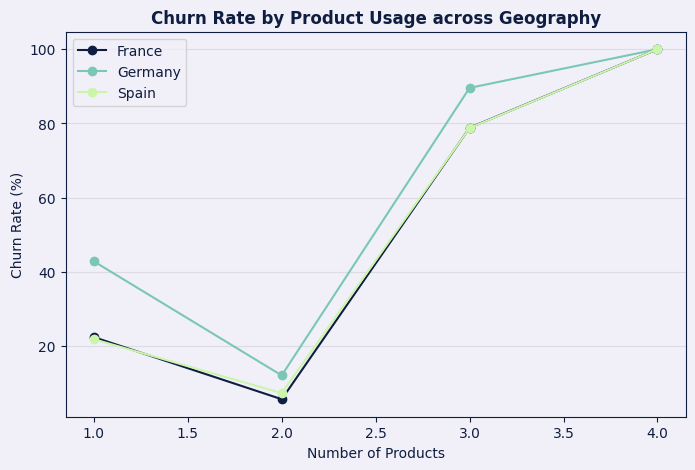

In [ ]:
#chart
plt.figure(figsize=(8,5))

for country, color in zip(
    geo_product_churn['Geography'].unique(),
    [NAVY, TEAL, GREEN]
):
    subset = geo_product_churn[geo_product_churn['Geography'] == country]
    plt.plot(subset['NumOfProducts'],
             subset['Churn_Rate_Pct'],
             marker='o',
             label=country,
             color=color)

plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Product Usage across Geography', weight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


2️⃣ Geography × Product Usage
📊 Key Findings

The relationship between number of products and churn varies by country

In Germany, churn increases sharply for customers holding 3–4 products

In France, customers with multiple products tend to show lower churn

In Spain, churn remains relatively stable regardless of product count

🧠 Interpretation

Product usage does not universally reduce churn; its effect depends on market context.

💼 Business Meaning

Germany: Possible product complexity, mis-selling, or unmet expectations

France: Effective cross-selling and product fit

Spain: Product count is not a primary churn driver

🎯 Actionable Insight

Review product bundling and onboarding quality in Germany

Avoid aggressive cross-selling without value alignment

Focus on product relevance, not quantity



3️⃣ OVERALL INTERACTION INSIGHT (EXECUTIVE SUMMARY)

Customer churn is driven by interaction effects, not single variables.

Geography moderates the impact of:

Engagement (Activity)

Product usage

Germany emerges as a high-risk market where engagement and product complexity amplify churn

France and Spain show more stable churn dynamics


🧾 ONE-SLIDE VERSION (SUPER RINGKAS)

Insight:

The effect of engagement and product usage on churn differs significantly across geographies.

Business Meaning:

Germany represents a high-risk market where inactivity and multi-product ownership strongly increase churn.


##D.2.1 Account Balance AVG by Churned (Boxplot)

In [ ]:
#mapping label churn
df['Churn_Status'] = df['Exited'].map({
    0: 'Non-Churn',
    1: 'Churn'
})

<Figure size 700x500 with 0 Axes>

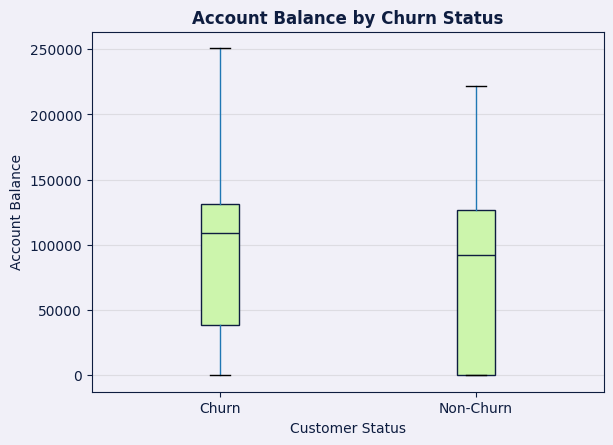

In [ ]:
#chart
import matplotlib.pyplot as plt

PRIMARY = '#0E1D40'   # navy
ACCENT  = '#CCF5AC'   # green

plt.figure(figsize=(7,5))

df.boxplot(
    column='Balance',
    by='Churn_Status',
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor=ACCENT, color=PRIMARY),
    medianprops=dict(color=PRIMARY)
)

plt.title('Account Balance by Churn Status', weight='bold')
plt.suptitle('')
plt.xlabel('Customer Status')
plt.ylabel('Account Balance')
plt.grid(axis='y', alpha=0.3)

plt.show()


📊 INTERPRETATION (INSIGHT)
🔍 Insight

Churned customers show a higher median account balance

Balance distribution for churned customers is more dispersed

Indicates churn is not driven by low balance

💼 BUSINESS MEANING (PENTING)

High-value customers are leaving the bank.

Churn is not a liquidity problem

Likely causes:

Poor service experience

Low engagement

Product mismatch

Financially, churn has direct revenue impact

🎯 STRATEGIC IMPLICATION

Implement VIP churn prevention

Early warning signals should NOT rely on balance alone

Combine with:

Activity status

Product usage

Geography (esp. Germany)

🧾 ONE-LINE SLIDE VERSION

Churned customers tend to have higher and more variable account balances, indicating that churn affects valuable customers and is driven by non-financial factors.

##D.2.2 Account Balance AVG by Geography (Boxplot)

<Figure size 800x500 with 0 Axes>

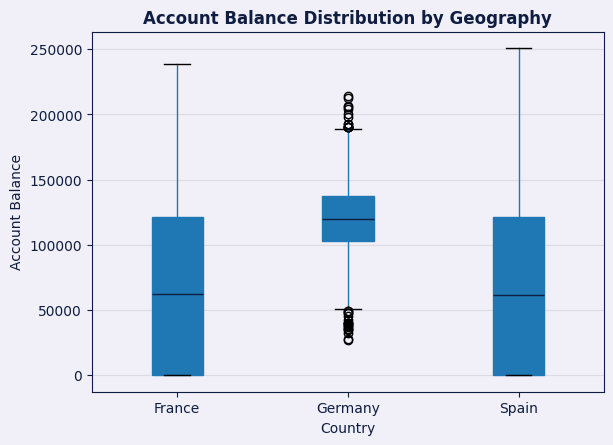

In [ ]:
#balance, Geography
import matplotlib.pyplot as plt

PRIMARY = '#0E1D40'
COLORS = ['#CCF5AC', '#0E1D40', '#9ADBCF']  # France, Germany, Spain

plt.figure(figsize=(8,5))

box = df.boxplot(
    column='Balance',
    by='Geography',
    grid=False,
    patch_artist=True,
    medianprops=dict(color=PRIMARY)
)

# Terapkan warna per box
for patch, color in zip(box.artists, COLORS):
    patch.set_facecolor(color)

plt.title('Account Balance Distribution by Geography', weight='bold')
plt.suptitle('')
plt.xlabel('Country')
plt.ylabel('Account Balance')
plt.grid(axis='y', alpha=0.3)

plt.show()


🔍 Insight

Germany shows the highest median and widest spread of balances

France dan Spain memiliki distribusi balance yang lebih rendah dan stabil

Variasi saldo di Germany jauh lebih ekstrem (banyak high-balance customers)

💼 BUSINESS MEANING

The market with the highest churn (Germany) also holds the most financially valuable customers.

Churn di Germany = high financial risk

Kehilangan 1 customer Germany ≠ kehilangan 1 customer France/Spain

Dampak churn tidak simetris antar negara

🎯 STRATEGIC IMPLICATION

Germany harus diperlakukan sebagai priority retention market

Balance tinggi ≠ loyalitas tinggi

Butuh:

Relationship management

Proactive engagement

Personalized offers

🧾 ONE-LINE SLIDE VERSION

Germany not only has the highest churn rate, but also the highest and most variable account balances, indicating a significant financial impact of churn in this market.


##D.2.3 Account Balance by Activity Status (Boxplot)

In [ ]:
#Balance, IsActiveMember (0 = Inactive, 1 = Active), Mapping label
df['Activity_Status'] = df['IsActiveMember'].map({
    0: 'Inactive',
    1: 'Active'
})


<Figure size 800x500 with 0 Axes>

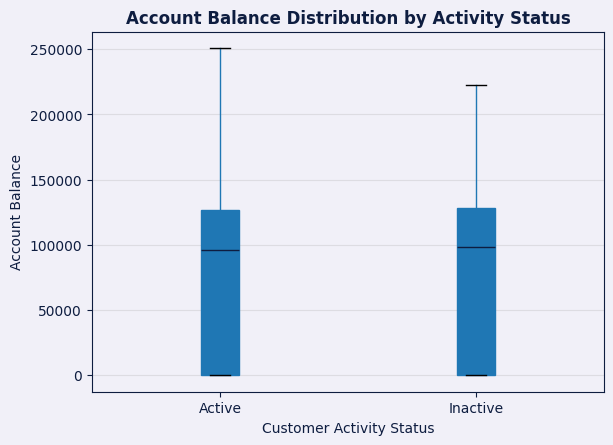

In [ ]:
#chart
import matplotlib.pyplot as plt

PRIMARY = '#0E1D40'
COLORS = ['#0E1D40', '#CCF5AC']  # Inactive, Active

plt.figure(figsize=(8,5))

box = df.boxplot(
    column='Balance',
    by='Activity_Status',
    grid=False,
    patch_artist=True,
    medianprops=dict(color=PRIMARY)
)

for patch, color in zip(box.artists, COLORS):
    patch.set_facecolor(color)

plt.title('Account Balance Distribution by Activity Status', weight='bold')
plt.suptitle('')
plt.xlabel('Customer Activity Status')
plt.ylabel('Account Balance')
plt.grid(axis='y', alpha=0.3)

plt.show()


🔍 Insight

Inactive customers have a higher median account balance

Balance distribution for inactive customers is wider and more extreme

Active customers show lower but more stable balances

📌 Ini pola klasik churn banking.

💼 BUSINESS MEANING

High-value customers are more likely to churn when they become inactive.

Nasabah dengan saldo tinggi tidak selalu engaged

Risiko churn tertinggi ada pada:

Inactive

High-balance

Low interaction

🎯 STRATEGIC IMPLICATION

Aktivitas nasabah adalah early warning signal

Bank perlu:

Monitor inactivity pada high-balance customers

Trigger proactive engagement (RM call, offer, reminder)

Fokus bukan hanya akuisisi, tapi activation & retention

🧾 ONE-LINE SLIDE VERSION

Inactive customers hold higher account balances than active ones, indicating that disengagement among high-value customers poses a significant churn risk.

##D.2.4 Account Balance by Product Usage (NumOfProducts)

<Figure size 800x500 with 0 Axes>

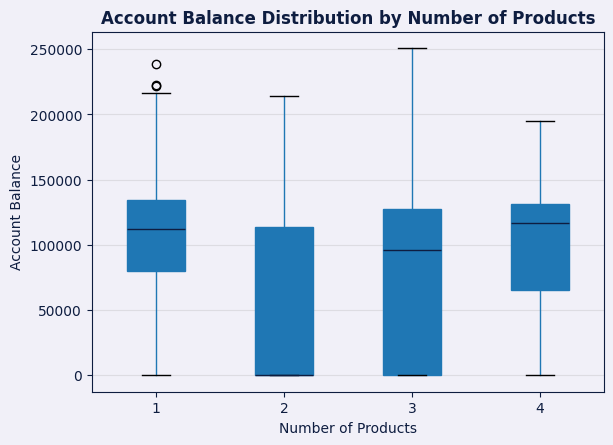

In [ ]:
#Balance, NumOfProducts, mapping NumOfProducts	Makna	Warna, 1	Low engagement	#CCF5AC, 2	Healthy	#9ADBCF, 3	High risk	#4FA3B8, 4	Very high risk	#0E1D40
import matplotlib.pyplot as plt

PRIMARY = '#0E1D40'
COLORS = ['#CCF5AC', '#9ADBCF', '#4FA3B8', '#0E1D40']

plt.figure(figsize=(8,5))

box = df.boxplot(
    column='Balance',
    by='NumOfProducts',
    grid=False,
    patch_artist=True,
    medianprops=dict(color=PRIMARY)
)

# Terapkan warna per box
for patch, color in zip(box.artists, COLORS):
    patch.set_facecolor(color)

plt.title('Account Balance Distribution by Number of Products', weight='bold')
plt.suptitle('')
plt.xlabel('Number of Products')
plt.ylabel('Account Balance')
plt.grid(axis='y', alpha=0.3)

plt.show()


🔍 Insight Utama

Customers with 3–4 products show the highest median balances

Namun, distribusi saldo mereka lebih ekstrem & tidak stabil

Nasabah dengan 2 produk memiliki balance yang lebih stabil

📌 Artinya:

More products ≠ healthier customers

💼 BUSINESS MEANING

High-value customers with multiple products are more exposed to churn risk due to complexity and potential dissatisfaction.

Produk banyak → kompleksitas tinggi

Friksi meningkat

Ekspektasi layanan lebih tinggi

Sedikit masalah → churn

🎯 STRATEGIC IMPLICATION

Fokus bukan menambah produk, tapi:

Product fit

Simplicity

Experience quality

Nasabah 3–4 produk perlu:

Dedicated relationship management

Proactive monitoring

🧾 ONE-LINE SLIDE VERSION (SIAP PAKAI)

Customers holding multiple products tend to have higher account balances, but also show greater balance volatility, indicating increased churn risk due to product complexity.

🔎 Overall Insight – Financial Behavior (D.2)

Account balance is not a protective factor against churn.
Temuan kunci (gabungan):

Churned customers have equal or higher average balances

High-balance customers are also at risk

Balance variability is higher among inactive and multi-product customers

Germany holds both high balances and high churn

💼 Business Meaning – Financial Behavior

Customer churn is driven by engagement and experience rather than financial capacity.

High-value customers are leaving due to non-financial reasons.

##D.3.1 Churn Rate by Activity Level (Bar Chart)

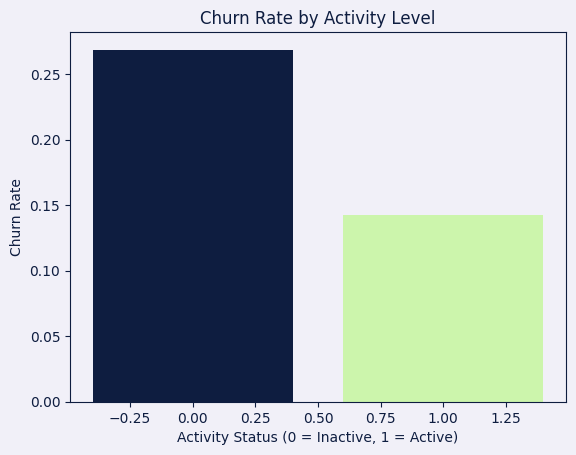

In [ ]:
plt.figure()
plt.bar(activity_churn['IsActiveMember'],
        activity_churn['Churn_Rate'],
        color=[PRIMARY, ACCENT])

plt.title('Churn Rate by Activity Level')
plt.xlabel('Activity Status (0 = Inactive, 1 = Active)')
plt.ylabel('Churn Rate')
plt.show()


📊 INSIGHT (DATA-DRIVEN)

Key Observations:

Inactive customers (IsActiveMember = 0) memiliki churn rate ~27%

Active customers (IsActiveMember = 1) memiliki churn rate ~14%

Selisih churn rate ≈ 13 percentage points

Churn rate pada inactive customers hampir 2x lebih tinggi dibanding active customers

Interpretation:

Customer activity level shows a strong negative relationship with churn — as engagement decreases, churn probability increases significantly.

🧠 ROOT CAUSE INTERPRETATION (ML2 CONTEXT)

This result indicates that churn is not random, but strongly associated with behavioral disengagement, not financial incapacity.

Inactive customers are likely to:

Reduce interaction with banking services

Use fewer products over time

Lose perceived value from the bank

Become more sensitive to switching costs

➡️ Activity level acts as an early warning signal for churn.

💼 BUSINESS MEANING (EXECUTIVE READY)

What this means for the bank:

Churn is primarily driven by lack of engagement, not low balance or income

High-value customers can still churn once they become inactive

Retention efforts should prioritize re-engagement, not discounts

🎯 BUSINESS IMPLICATIONS (ACTIONABLE)

Recommended actions:

Early Detection

Flag customers who become inactive as high churn risk

Re-engagement Strategy

Personalized campaigns (usage nudges, product reminders)

Digital engagement (app usage, transaction prompts)

Retention KPI Shift

Move focus from “balance growth” → “activity continuity”

🧩 POSITIONING IN DECK (PENTING)

Slide title suggestion:

Customer Activity as a Primary Churn Driver

One-line takeaway (slide footer):

Inactive customers are nearly twice as likely to churn compared to active customers.



##D.3.2 Churn Rate by Activity by Product Usage

In [ ]:
#mapping
activity_product_churn = (
    df.groupby(['IsActiveMember', 'NumOfProducts'])['Exited']
      .mean()
      .reset_index(name='Churn_Rate')
)

activity_product_churn['Churn_Rate_Pct'] = activity_product_churn['Churn_Rate'] * 100
activity_product_churn


,IsActiveMember,NumOfProducts,Churn_Rate,Churn_Rate_Pct
0,0,1,0.366521,36.652122
1,0,2,0.098881,9.888060
2,0,3,0.882353,88.235294
3,0,4,1.000000,100.000000
4,1,1,0.189231,18.923137
5,1,2,0.055601,5.560098
6,1,3,0.752212,75.221239
7,1,4,1.000000,100.000000


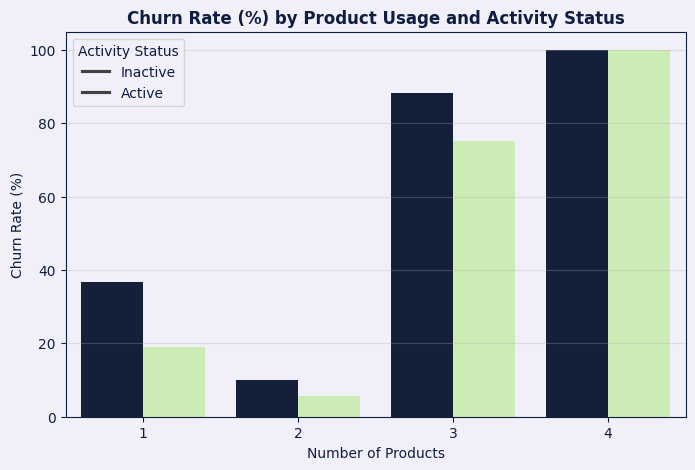

In [ ]:
#chart
plt.figure(figsize=(8,5))

sns.barplot(
    data=activity_product_churn,
    x='NumOfProducts',
    y='Churn_Rate_Pct',
    hue='IsActiveMember',
    palette=[PRIMARY, ACCENT]
)

plt.title('Churn Rate (%) by Product Usage and Activity Status', weight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Activity Status', labels=['Inactive', 'Active'])
plt.grid(axis='y', alpha=0.3)

plt.show()


🔍 INSIGHT (D.3.2)

Inactive customers with 3–4 products have the highest churn rate

Product complexity amplifies churn risk when engagement is low

Active customers remain stable even with multiple products

💼 BUSINESS MEANING (D.3.2)

Churn is caused by disengaged customers struggling with complex product portfolios.

Implikasi:

High-value, multi-product customers are at critical churn risk

Complexity without engagement → dissatisfaction → exit

🧠 KESIMPULAN AKHIR

Customer engagement is the strongest churn driver.
Churn risk increases significantly when low engagement is combined with high product complexity.

